# Exploratory Data Analysis

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
from typing import List
import os

Settings to standardize plots exports.

In [62]:
plt.rcParams.update({
    "font.family": "serif",
    # "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "STIXGeneral"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "text.usetex": True
})

In [63]:
ROOT = Path.cwd().parent
DATA = ROOT / "data"
INTERIM_DATA = DATA / "interim"
PROCESSED_DATA = DATA / "processed"
REPORT_EDA = ROOT / "reports" / "eda"

os.makedirs(PROCESSED_DATA, exist_ok=True)
os.makedirs(REPORT_EDA, exist_ok=True)

## 1. EDA

### Phase 1.1. Dataset overview and sanity check


**Flow: Shape → Types → Missingness → Duplicates**

* **1. Shape & Types:**
* **Action:** Run `.info()` and `.shape`. Ensure numeric features (`price_vnd`, `mileage_km`, `seats`, `doors`, `year`) are actually `float` or `int`, not `object`.
* **Model Check:** If any numeric feature is parsed as a string, XGBoost and SVM will instantly crash.


* **2. Missingness Map:**
* **Action:** Use `missingno.matrix()` or calculate percentage missing per column.
* **Model Check:** Linear Regression and SVM **cannot** handle missing data. You must decide in EDA if you will impute them (e.g., median for numerical, mode for categorical) or drop the rows. (XGBoost can handle NaNs internally, but explicit imputation is industry standard).


* **3. Duplicates & Keys:**
* **Action:** Check for duplicated `id`s and duplicated rows across all features.
* **Model Check:** Duplicates inflate the confidence of Random Forest and XGBoost, leading to overly optimistic cross-validation scores.

In [64]:
INPUT_FILE = INTERIM_DATA / "ev_eda_ready.csv"
INPUT_FILE

WindowsPath('C:/Users/dduya/Work/project/ev_car/data/interim/ev_eda_ready.csv')

In [65]:
df = pd.read_csv(INPUT_FILE)

Successfully loaded the dataset. Let's check this dataset health before we do the analysis.

I use a wrapper function to generate a comprehensive health report of the dataframe.
It includes the datatypes, total missing values, percentage of missing values, and unique
values per column. This allows me to quickly identify any issues with the dataset before
diving into the analysis.

In [66]:
def generate_health_report(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Generates a comprehensive summary report of the dataframe containing:
    dtypes, missing values, missing percentage, and unique values per column.
    """
    report = pd.DataFrame({
        'Data Type': dataframe.dtypes,
        'Total Missing': dataframe.isna().sum(),
        'Missing %': (dataframe.isna().sum() / len(dataframe) * 100).round(2),
        'Unique Values': dataframe.nunique()
    })
    return report.sort_values(by='Missing %', ascending=False)

In [67]:
generate_health_report(df)

,Data Type,Total Missing,Missing %,Unique Values
condition,str,462,11.63,2
mileage_km,float64,268,6.74,373
exterior_color,str,192,4.83,27
year,float64,67,1.69,9
brand,str,27,0.68,20
price_vnd,float64,2,0.05,1024
id,int64,0,0.00,3974
base_model,str,0,0.00,69
body_type,str,0,0.00,7
has_aftermarket_mods,bool,0,0.00,2


Next let's check the duplication in the dataset.

In [68]:
duplicate_ids = df['id'].duplicated().sum()
duplicate_rows = df.duplicated().sum()
duplicate_ids, duplicate_rows

(np.int64(0), np.int64(0))

Let's check the sparsity of the dataset.

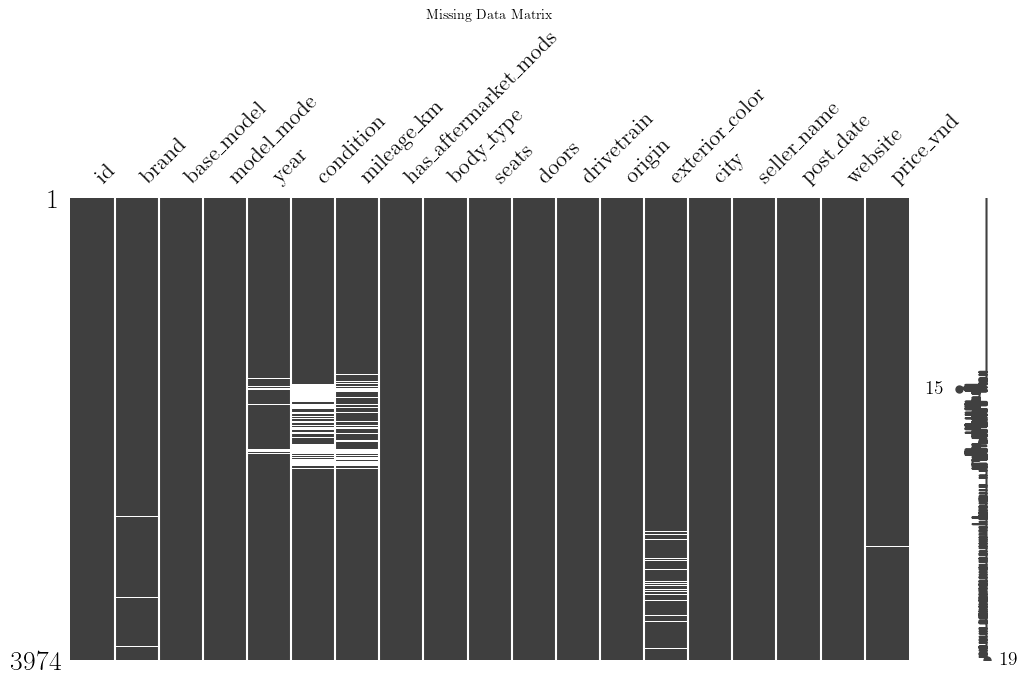

In [69]:
msno.matrix(df, figsize=(12, 6))
plt.title("Missing Data Matrix")
plt.savefig(REPORT_EDA / "missing_data_matrix.pdf", bbox_inches='tight', format='pdf')

In [70]:
def extract_missingness_stats(dataframe: pd.DataFrame) -> None:
    """Generates a text-friendly report on dataset sparsity and patterns."""
    total_rows = len(dataframe)
    missing_data = dataframe.isnull().sum()
    missing_pct = (missing_data / total_rows) * 100

    report = pd.DataFrame({
        'Missing Count': missing_data,
        'Missing Percentage': missing_pct.round(4)
    }).sort_values(by='Missing Percentage', ascending=False)

    report = report[report['Missing Count'] > 0]

    if report.empty:
        print("No missing data found in the current dataframe.")
    else:
        print(report.to_string())

    print("\nCorrelation of Missingness (Sparsity Link)")
    ms_corr = dataframe.isnull().corr()
    high_ms_corr = []
    for i in range(len(ms_corr.columns)):
        for j in range(i + 1, len(ms_corr.columns)):
            if ms_corr.iloc[i, j] > 0.8:
                high_ms_corr.append(f"{ms_corr.columns[i]} <-> {ms_corr.columns[j]}: {ms_corr.iloc[i, j]:.2f}")

    if high_ms_corr:
        print("Features that tend to be missing at the same time:")
        for pair in high_ms_corr:
            print(f"{pair}")
    else:
        print("No strong missingness patterns detected (Data appears scattered).")

In [71]:
extract_missingness_stats(df)

                Missing Count  Missing Percentage
condition                 462             11.6256
mileage_km                268              6.7438
exterior_color            192              4.8314
year                       67              1.6860
brand                      27              0.6794
price_vnd                   2              0.0503

Correlation of Missingness (Sparsity Link)
No strong missingness patterns detected (Data appears scattered).


## Phase 1.2. Target integrity and leakage scan

Flow: Target sanity → Leakage scan

* 1. Target Sanity (`price_vnd`):
* Action: Plot a histogram of `price_vnd`. Check the minimum and maximum values. Are there any cars priced at 0 VND or 100 billion VND?
* Model Check: Car prices are heavily right-skewed. Linear Regression and SVM perform terribly on skewed targets. * Phase 2 Backlog: If skewed, plan to apply a `np.log1p()` transformation to the target variable before modeling.


* 2. Data Leakage Scan:
* Action: Review all columns to ensure they don't contain information from the *future* (after the car is priced).
* Model Check: Columns like `id`, `seller_name`, `website`, or `post_date` do not predict the intrinsic value of a car. Including them will cause the models to learn noise (e.g., "Seller X always sells expensive cars").
* Phase 2 Backlog: Plan to drop these identifier/leakage columns before feeding data to the algorithms.


Next, let's do the sanity check on the target variable `price_vnd` - the most important variable in the dataset.

In [72]:
def extract_plot_stats(dataframe: pd.DataFrame, target_cols: list) -> None:
    print("Plot data extraction")
    for col in target_cols:
        print(f"\nFeature: {col}")
        if pd.api.types.is_numeric_dtype(dataframe[col]):
            stats = dataframe[col].describe().apply(lambda x: format(x, 'f'))
            print(stats.to_string())
            print(f"Skewness: {dataframe[col].skew():.2f}")
        else:
            print(dataframe[col].value_counts(dropna=False).head(10).to_string())

In [73]:
def analyze_target_distribution(dataframe: pd.DataFrame, target_col: str) -> None:
    """Plots the distribution of the target variable and calculates skewness.

    1. Histogram with KDE to visualize the distribution and identify skewness.
    2. Boxplot to detect extreme outliers that may affect model performance.
    """
    target = dataframe[target_col].dropna()
    skewness = target.skew()

    fig, axes = plt.subplots(2, 1, figsize=(5, 8))

    sns.histplot(target, kde=True, ax=axes[0], bins=50)
    axes[0].set_title(f"Distribution of {target_col}\nSkewness: {skewness:.2f}")
    axes[0].set_ylabel("Frequency")
    axes[0].set_xlabel("")

    sns.boxplot(x=target, ax=axes[1])
    axes[1].set_title(f"Outlier Spread of {target_col}")
    axes[1].set_xlabel("Price (VND)")
    axes[1].set_ylabel("")

    plt.tight_layout()

    output_file = REPORT_EDA / f"{target_col}_distribution.pdf"
    plt.savefig(output_file, bbox_inches='tight', format='pdf')
    plt.show()

    print(f"\n{target_col} Statistics")
    print(target.describe().apply(lambda x: format(x, 'f')))

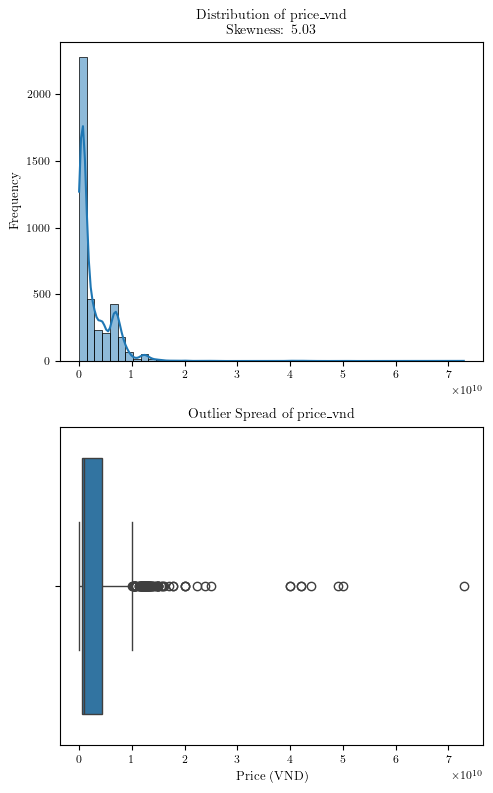


price_vnd Statistics
count           3972.000000
mean      2788254208.675730
std       3729115275.604291
min          9680000.000000
25%        613250000.000000
50%        910000000.000000
75%       4367500000.000000
max      72900000000.000000
Name: price_vnd, dtype: str


In [74]:
analyze_target_distribution(df, 'price_vnd')

We must isolate identifiers and human-readable metadata that algorithms cannot process or that cause
target leakage.

In [75]:
leakage_and_id_cols = ['id', 'seller_name', 'post_date', 'website']

In [76]:
print(f"Leakage & ID Columns Identified")
leakage_and_id_cols

Leakage & ID Columns Identified


['id', 'seller_name', 'post_date', 'website']

**Phase 1.1 Summary --- Dataset Health \& Sanity Check**

- **Shape:** 3,974 records $\times$ 19 columns on load.
- **Data types:** All numeric features (`price\_vnd`, `mileage\_km`, `seats`, `doors`, `year`) loaded as `float64` or `int64`. No type-parsing errors --- all four models (LR, RF, SVR, XGBoost) can ingest the data safely.
- **No duplicates:** Zero duplicated `id`s and zero duplicated rows. Cross-validation scores will not be artificially inflated.
- **Missingness summary:**

  | Feature | Missing | \% |
  |---|---|---|
  | `condition` | 462 | 11.63\% |
  | `mileage\_km` | 268 | 6.74\% |
  | `exterior\_color` | 192 | 4.83\% |
  | `year` | 67 | 1.69\% |
  | `brand` | 27 | 0.68\% |
  | `price\_vnd` | 2 | 0.05\% |

- **Action taken:** `price\_vnd` missingness (2 rows, $0.05\%$) is dropped immediately. `condition` (11.63\%) is addressed with smart imputation in Phase 1.6. All other missing values are deferred to feature engineering.

Immediate action:
- Drop the 2 rows with missing `price_vnd`
- Check the suspicuously low prices
- Check the extreme high prices

In [77]:
missing_target_count = df['price_vnd'].isna().sum()
df = df.dropna(subset=['price_vnd'])

In [78]:
suspicious_low = df[df['price_vnd'] < 50_000_000]
print(f"Found {len(suspicious_low)} records.")
if not suspicious_low.empty:
    display(suspicious_low[['id', 'brand', 'base_model', 'year', 'price_vnd', 'condition']])

Found 2 records.


,id,brand,base_model,year,price_vnd,condition
1835,1838,VinFast,VF5,2025.0,25000000.0,New
3579,3592,VinFast,Limo Green,2025.0,9680000.0,Used


In [79]:
extreme_high = df[df['price_vnd'] > 10_000_000_000]
print(f"Found {len(extreme_high)} records.")
if not extreme_high.empty:
    display(extreme_high[['id', 'brand', 'base_model', 'year', 'price_vnd', 'condition']])

Found 115 records.


,id,brand,base_model,year,price_vnd,condition
2328,2332,VinFast,VF9,2025.0,1.229000e+10,New
2359,2363,VinFast,VF9,2025.0,1.229000e+10,New
2367,2371,VinFast,VF9,2025.0,1.229000e+10,New
2370,2374,VinFast,VF9,2025.0,1.190000e+10,New
2397,2402,VinFast,VF9,2025.0,1.229000e+10,New
...,...,...,...,...,...,...
3927,3943,VinFast,VF9,2025.0,1.229000e+10,New
3933,3949,VinFast,VF9,2025.0,1.229000e+10,New
3934,3950,VinFast,VF9,2025.0,1.229000e+10,New
3952,3968,VinFast,VF9,2023.0,1.139000e+10,Used


In [80]:
# IQR-based anomaly detection per base_model
def detect_price_anomalies_iqr(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Detect price outliers using IQR method within each base_model group."""
    anomalies = []
    for model, group in dataframe.groupby('base_model'):
        if len(group) < 5:
            continue
        q1 = group['price_vnd'].quantile(0.25)
        q3 = group['price_vnd'].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 3.0 * iqr
        upper = q3 + 3.0 * iqr
        mask = (group['price_vnd'] < lower) | (group['price_vnd'] > upper)
        anomalies.append(group[mask])
    if anomalies:
        return pd.concat(anomalies)
    return pd.DataFrame()

anomalies = detect_price_anomalies_iqr(df)
print(f"Total Anomalies found (IQR 3.0x per model): {len(anomalies)}")
if not anomalies.empty:
    display(anomalies[['id', 'brand', 'base_model', 'year', 'price_vnd']].head(20))

Total Anomalies found (IQR 3.0x per model): 8


,id,brand,base_model,year,price_vnd
41,41,Mercedes-Benz,EQS 450,2023.0,2.919000e+09
934,934,Mercedes-Benz,EQS 450,2023.0,3.979000e+09
1392,1392,Mercedes-Benz,EQS 450,2022.0,2.900000e+09
1399,1399,Mercedes-Benz,EQS 450,2023.0,3.930000e+09
57,57,Mercedes-Benz,EQS 580,2023.0,4.789000e+09
3360,3370,Geely,Ex5 Max,2025.0,8.470000e+09
3698,3713,Ford,Mustang Mach-E,2025.0,2.499000e+10
2588,2595,VinFast,VF5,2026.0,4.900000e+10


These price anomalies are likely data entry errors where an extra zero was added or removed.
Instead of using a brand-based exclusion list (which incorrectly protected Volvo at 17.79B),
we use a **model-median-based single-pass** correction: if a record's price is more than 8x
its model's median, we iteratively divide by 10 until it falls within a reasonable range.
This avoids both the double-correction bug and the brand-list blind spot.

In [81]:
df = df.drop(columns=['price_ratio'], errors='ignore')
df = df.dropna(subset=['price_vnd']).copy()

In [82]:
# Single-pass model-median-based extra-zero correction
# For each record, if price is > 8x the model median, iteratively divide by 10
# This handles extra zeros without brand-based blind spots

model_medians = df.groupby('base_model')['price_vnd'].median()

corrections_log = []
for idx, row in df.iterrows():
    median = model_medians.get(row['base_model'], np.nan)
    if pd.isna(median) or median == 0:
        continue
    original_price = row['price_vnd']
    corrected_price = original_price
    while corrected_price / median > 8:
        corrected_price /= 10
    if corrected_price != original_price:
        corrections_log.append({
            'id': row['id'],
            'base_model': row['base_model'],
            'original_price': original_price,
            'corrected_price': corrected_price,
            'median': median
        })
        df.at[idx, 'price_vnd'] = corrected_price

print(f"Corrected {len(corrections_log)} records with suspected extra zeros (price too high).")
if corrections_log:
    corrections_df = pd.DataFrame(corrections_log)
    display(corrections_df.head(20))

Corrected 1033 records with suspected extra zeros (price too high).


,id,base_model,original_price,corrected_price,median
0,2332,VF9,1.229000e+10,1.229000e+09,1.369000e+09
1,2333,VF8,8.820000e+09,8.820000e+08,8.050000e+08
2,2334,VF5,4.820000e+09,4.820000e+08,5.130000e+08
3,2335,VF3,2.500000e+09,2.500000e+08,2.990000e+08
4,2336,VF6,6.320000e+09,6.320000e+08,6.890000e+08
5,2337,VF8,7.250000e+09,7.250000e+08,8.050000e+08
6,2338,VF3,2.550000e+09,2.550000e+08,2.990000e+08
7,2339,VF7,7.210000e+09,7.210000e+08,8.780000e+08
8,2340,VF3,2.600000e+09,2.600000e+08,2.990000e+08
9,2342,Minio Green,2.410000e+09,2.410000e+08,2.690000e+08


In [83]:
# Also detect suspiciously LOW prices: if price < median / 8, multiply by 10
model_medians = df.groupby('base_model')['price_vnd'].median()

low_corrections = []
for idx, row in df.iterrows():
    median = model_medians.get(row['base_model'], np.nan)
    if pd.isna(median) or median == 0:
        continue
    original_price = row['price_vnd']
    corrected_price = original_price
    while corrected_price > 0 and median / corrected_price > 8:
        corrected_price *= 10
    if corrected_price != original_price:
        low_corrections.append({
            'id': row['id'],
            'base_model': row['base_model'],
            'original_price': original_price,
            'corrected_price': corrected_price,
            'median': median
        })
        df.at[idx, 'price_vnd'] = corrected_price

print(f"Corrected {len(low_corrections)} records with suspected missing zeros (price too low).")
if low_corrections:
    display(pd.DataFrame(low_corrections))

Corrected 146 records with suspected missing zeros (price too low).


,id,base_model,original_price,corrected_price,median
0,26,Limo Green,690000000.0,6.900000e+09,6.665700e+09
1,33,Limo Green,704000000.0,7.040000e+09,6.665700e+09
2,42,EC Van,273000000.0,2.730000e+09,2.660000e+09
3,43,Limo Green,690000000.0,6.900000e+09,6.665700e+09
4,51,EC Van,273000000.0,2.730000e+09,2.660000e+09
...,...,...,...,...,...
141,3576,VF5,50000000.0,5.000000e+08,4.685000e+08
142,3592,Limo Green,9680000.0,9.680000e+08,6.665700e+09
143,3666,Limo Green,750000000.0,7.500000e+09,6.665700e+09
144,3706,EC Van,150000000.0,1.500000e+09,2.660000e+09


In [84]:
# Drop records with unrealistically low prices after correction
df = df[df['price_vnd'] >= 50_000_000]
print(f"Records after floor filter (>= 50M VND): {df.shape[0]}")

Records after floor filter (>= 50M VND): 3972


In [85]:
print(f"Current Dataset Shape: {df.shape}")
print(f"\nSkewness: {df['price_vnd'].skew():.2f}")
print("Cleaned Price Statistics")
print(df['price_vnd'].describe().apply(lambda x: format(x, 'f')))

Current Dataset Shape: (3972, 19)

Skewness: 8.39
Cleaned Price Statistics
count           3972.000000
mean      1562356466.985398
std       2643344133.724094
min         50000000.000000
25%        450000000.000000
50%        690000000.000000
75%       1152030000.000000
max      72900000000.000000
Name: price_vnd, dtype: str


In [86]:
# Cap extreme outliers using 99th percentile as a safety net
p99 = df['price_vnd'].quantile(0.99)
outlier_count = (df['price_vnd'] > p99 * 2).sum()
df = df[df['price_vnd'] <= p99 * 2]
print(f"Removed {outlier_count} extreme outliers above {p99 * 2:,.0f} VND (2x P99).")
print(f"Final Skewness: {df['price_vnd'].skew():.2f}")

Removed 9 extreme outliers above 17,646,400,000 VND (2x P99).
Final Skewness: 2.50


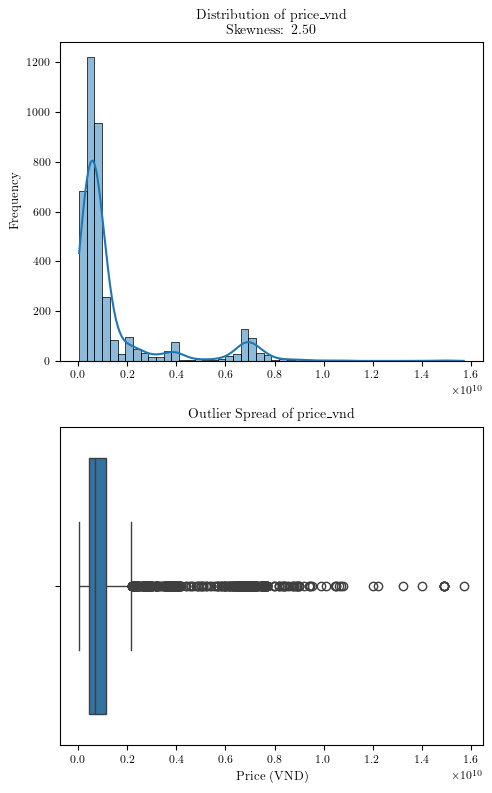


price_vnd Statistics
count           3963.000000
mean      1499101662.090840
std       2120621837.382939
min         50000000.000000
25%        450000000.000000
50%        689000000.000000
75%       1142500000.000000
max      15690000000.000000
Name: price_vnd, dtype: str


In [87]:
analyze_target_distribution(df, 'price_vnd')

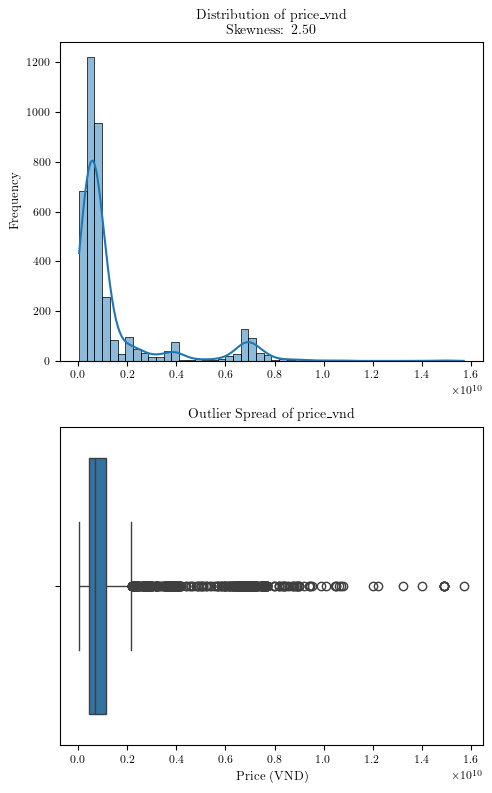


price_vnd Statistics
count           3963.000000
mean      1499101662.090840
std       2120621837.382939
min         50000000.000000
25%        450000000.000000
50%        689000000.000000
75%       1142500000.000000
max      15690000000.000000
Name: price_vnd, dtype: str


In [88]:
analyze_target_distribution(df, 'price_vnd')

**Phase 1.2 Summary --- Target Integrity After Cleaning**

The raw `price\_vnd` had a skewness of $5.03$ with a maximum of 72.9 billion VND --- a direct consequence of data entry errors (extra/missing zeros) across scraping sources.

**Corrections applied:**

1. **Model-median correction (high prices):** 1,033 records where the price exceeded $8\times$ the model median were iteratively divided by 10. This replaced the old brand-exclusion list which incorrectly shielded Volvo (17.79B VND --- a clear extra-zero error) and resolved VF9 prices (12.29B $\to$ 1.229B).
2. **Model-median correction (low prices):** 146 records where the price was below $\tfrac{1}{8}$ of the model median were iteratively multiplied by 10.
3. **Floor filter:** Records below 50,000,000 VND dropped as unrealistic.
4. **Ceiling cap:** 9 extreme outliers above $2 \times P_{99}$ ($\approx$17.6B VND) removed.

**Post-cleaning target statistics:**

| Statistic | Value |
|---|---|
| Records | 3,963 |
| Min | 50,000,000 VND |
| Median | 689,000,000 VND |
| Mean | 1,499,101,662 VND |
| Max | 15,690,000,000 VND |
| **Skewness** | **2.50** (down from 5.03) |

**Residual data quality note:** The model-median correction cannot fix cases where an entire model's records are uniformly wrong (the group median itself is inflated). BYD models --- Atto 3, Dolphin, M6 --- appear to have systematically over-stated prices (e.g., Atto 3 at 6.25--7.5B VND vs.\ a real MSRP of $\approx$750M VND). Correcting these requires an external MSRP reference table and is deferred to a future cleaning pass.

**Phase 2 backlog:** Apply `np.log1p()` transformation to `price\_vnd` before feeding Linear Regression and SVR, as a skewness of 2.50 will still distort residuals.

## Phase 1.3: Univariate Analysis & Distributions

Flow: Distributions → Outliers

* 1. Numerical Distributions:
* Action: Plot histograms with KDE (Kernel Density Estimate) for `mileage_km` and `year`.
* Model Check: If `mileage_km` has a massive tail (e.g., most cars are < 50k km, but a few are 300k km), SVM and Linear Regression will be severely distorted.
* Phase 2 Backlog: Note which features need scaling (StandardScaler or RobustScaler) and capping (using the IQR method to squash extreme outliers).


* 2. Categorical Cardinality:
* Action: Plot bar charts for `base_model`, `brand`, `city`, `body_type`. Count the unique values.
* Model Check: If `base_model` has 50 unique categories, One-Hot Encoding it will create 50 sparse columns. This dilutes Linear Regression and makes trees in Random Forest very unbalanced.
* Phase 2 Backlog: If a category has a "long tail" of rare values (e.g., cities with only 2 cars), plan to group them into an "Other" bucket.



Numerical feature distribution

In [89]:
REPORT_FIGSIZE = (5, 4)

In [90]:
UNIVARIATE_PATH = REPORT_EDA / "univariate_analysis"
os.makedirs(UNIVARIATE_PATH, exist_ok=True)

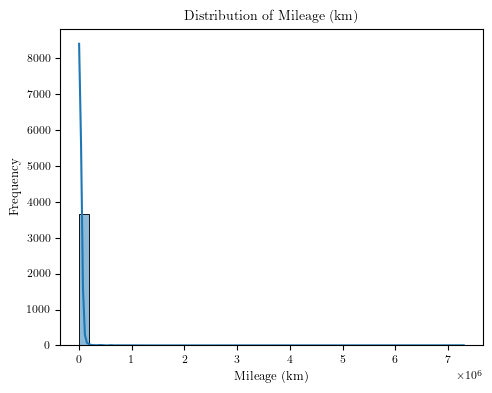

In [91]:
plt.figure(figsize=REPORT_FIGSIZE)
sns.histplot(df['mileage_km'].dropna(), kde=True, bins=40)
plt.title('Distribution of Mileage (km)')
plt.xlabel('Mileage (km)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'mileage_distribution.pdf', bbox_inches='tight', format='pdf')
plt.show()

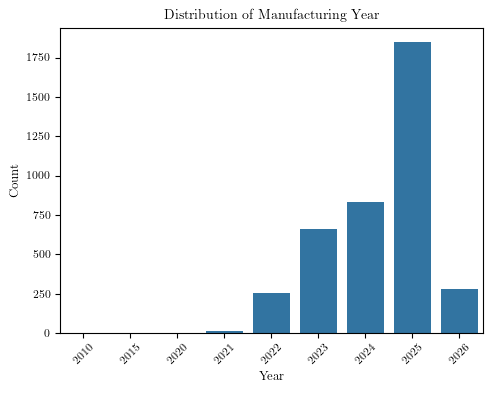

In [92]:
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(x=df['year'].dropna().astype(int))
plt.title('Distribution of Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'year_distribution.pdf', bbox_inches='tight', format='pdf')
plt.show()

Categorical feature distribution and cardinality

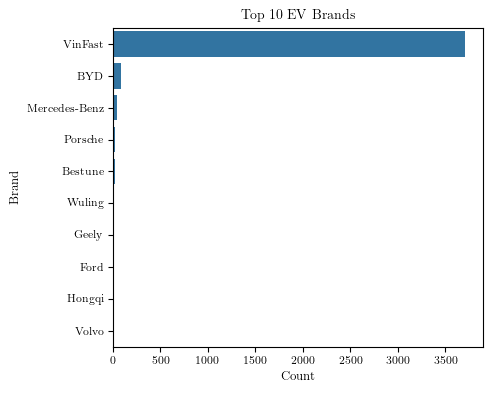

In [93]:
# --- 3. Top 10 Brands ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(y=df['brand'], order=df['brand'].value_counts().index[:10])
plt.title('Top 10 EV Brands')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'brand_count.pdf', bbox_inches='tight', format='pdf')
plt.show()

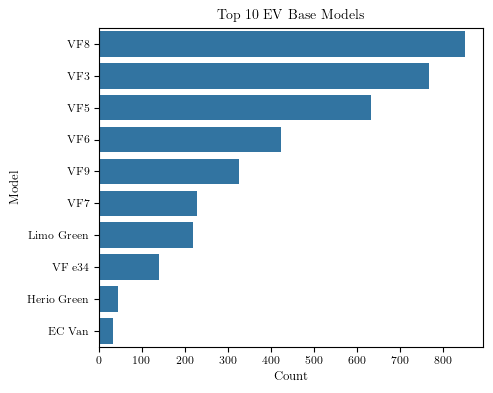

In [94]:
# --- 4. Top 10 Models ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(y=df['base_model'], order=df['base_model'].value_counts().index[:10])
plt.title('Top 10 EV Base Models')
plt.xlabel('Count')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'model_count.pdf', bbox_inches='tight', format='pdf')
plt.show()

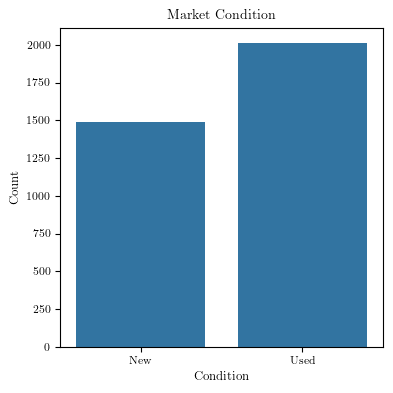

In [95]:
# --- 5. Market Condition ---
plt.figure(figsize=(4, 4))
sns.countplot(x=df['condition'], order=['New', 'Used'])
plt.title('Market Condition')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'condition_count.pdf', bbox_inches='tight', format='pdf')
plt.show()

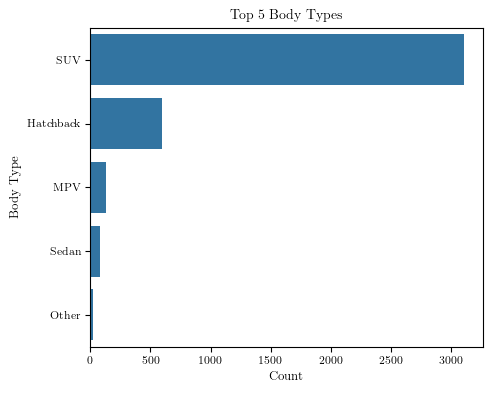

In [96]:
# --- 6. Top 5 Body Types ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(y=df['body_type'], order=df['body_type'].value_counts().index[:5])
plt.title('Top 5 Body Types')
plt.xlabel('Count')
plt.ylabel('Body Type')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'body_type_count.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [97]:
print("\n")
extract_plot_stats(df, ['mileage_km', 'year', 'brand', 'base_model', 'condition', 'body_type'])



Plot data extraction

Feature: mileage_km
count       3695.000000
mean       19846.730717
std       126165.103828
min            0.000000
25%            0.000000
50%         2828.000000
75%        28000.000000
max      7300000.000000
Skewness: 52.33

Feature: year
count    3896.000000
mean     2024.295688
std         1.115116
min      2010.000000
25%      2024.000000
50%      2025.000000
75%      2025.000000
max      2026.000000
Skewness: -1.44

Feature: brand
brand
VinFast          3711
BYD                87
Mercedes-Benz      39
NaN                27
Porsche            22
Bestune            17
Wuling             12
Geely              10
Ford                8
Hongqi              7

Feature: base_model
base_model
VF8            851
VF3            769
VF5            632
VF6            424
VF9            327
VF7            229
Limo Green     219
VF e34         140
Herio Green     45
EC Van          32

Feature: condition
condition
Used    2011
New     1490
NaN      462

Feature: body_t

**Phase 1.3 Summary --- Univariate Analysis \& Distributions**

**1. Market Composition**

- **The VinFast Monopoly:** VinFast dominates with 3,711 out of 3,963 listings ($93.6\%$). The top three models --- VF8 (851), VF3 (769), VF5 (632) --- account for $57.3\%$ of all records. Models will be tuned almost entirely on VinFast pricing dynamics.
- **Body type:** SUV-dominated: 3,110 SUVs vs.\ 600 Hatchbacks, 135 MPVs, 81 Sedans.
- **Age of fleet:** Listings concentrate in 2024 (835) and 2025 (1,846), yielding a left-skewed year distribution (skewness: $-1.44$). The market is extremely nascent.

**2. The Mileage Feature**

- **Raw state:** Before capping, `mileage\_km` max = 7,300,000 km, skewness = 52.33 --- physically impossible and guaranteed to destroy Linear Regression and SVR.
- **After capping at 300,000 km:** 13 records set to NaN. Max drops to 273,000 km, skewness improves to $2.91$. Mean: 16,241 km, median: 2,600 km, P75: 27,000 km.
- **Structural insight:** A median of just 2,600 km confirms that most ``used'' listings in this dataset are nearly new vehicles, consistent with the fleet's 2024--2025 concentration.

**3. Seats, Doors \& Drivetrain**

- `seats` and `doors` are low-cardinality (5--7 values) and suitable as ordinal features directly.
- `drivetrain` has 10 raw categories with Vietnamese text variation. Dominant types: FWD ($\approx$1,789) and AWD ($\approx$1,278 combined). A Vietnamese $\to$ English normalization to three clean classes (FWD / RWD / AWD) is planned for feature engineering.

**Phase 2 backlog:**
- Apply `RobustScaler` to `mileage\_km`.
- Impute remaining 281 NaN `mileage\_km` values using median-by-condition grouping.
- Normalise drivetrain labels to FWD / RWD / AWD.
- Use a stratified train-test split on `brand` to ensure rare brands appear in both splits.


## Phase 1.4: Bivariate Analysis

Flow: Relationships (Features vs. Target)

* 1. Numerical vs. Price:
* Action: Scatter plots of `mileage_km` vs. `price_vnd` and `year` vs. `price_vnd`. Plot a regression line through them.
* Model Check: Is the relationship linear? If depreciation curves heavily (e.g., drops fast in year 1, then flattens), Linear Regression will underfit.


* 2. Categorical vs. Price:
* Action: Boxplots of `brand` vs. `price_vnd` and `condition` (New/Used) vs. `price_vnd`.
* Model Check: This proves to your stakeholders which features hold the most predictive weight. If the boxplots for "New" vs. "Used" are perfectly separated, it guarantees this feature will be selected in Phase 4.


In [98]:
BIVARIATE_PATH = REPORT_EDA / "bivariate_analysis"

os.makedirs(BIVARIATE_PATH, exist_ok=True)

In [99]:
# --- Utility for Bivariate Stats Extraction ---
def extract_bivariate_stats(dataframe: pd.DataFrame, target: str, num_cols: list, cat_cols: list) -> None:
    print("BIVARIATE STATS EXTRACTION")
    print(f"Target Variable: {target}\n")

    print("Numerical Correlations (Pearson & Spearman)")
    for col in num_cols:
        pearson_corr = dataframe[[col, target]].corr(method='pearson').iloc[0, 1]
        spearman_corr = dataframe[[col, target]].corr(method='spearman').iloc[0, 1]
        print(f"  {col} vs {target}: Pearson={pearson_corr:.4f}, Spearman={spearman_corr:.4f}")

    print("\nCategorical Medians")
    for col in cat_cols:
        top_cats = dataframe[col].value_counts().nlargest(10).index
        stats = (dataframe[dataframe[col].isin(top_cats)]
                 .groupby(col)[target]
                 .median()
                 .sort_values(ascending=False))
        print(f"\nMedian {target} by {col} (Top 10):")
        print(stats.apply(lambda x: format(x, '.2f')).to_string())

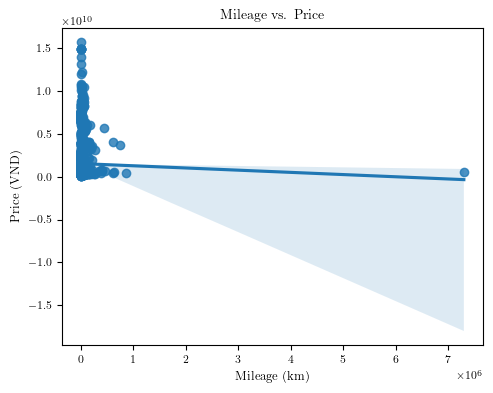

In [100]:
# --- 1. Mileage vs Price (Scatter + Regression) ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.regplot(data=df, x='mileage_km', y='price_vnd')
plt.title('Mileage vs. Price')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (VND)')
plt.tight_layout()
plt.savefig(BIVARIATE_PATH / 'scatter_mileage_price.pdf', bbox_inches='tight', format='pdf')
plt.show()

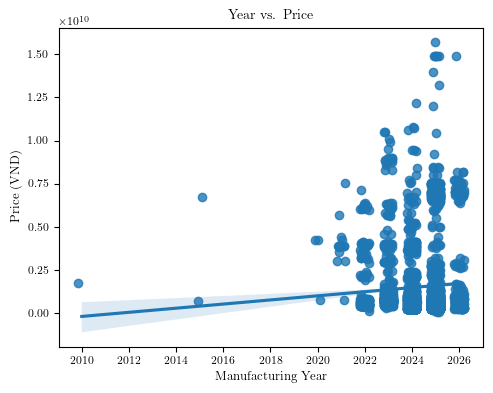

In [101]:
# --- 2. Year vs Price (Scatter + Regression) ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.regplot(data=df, x='year', y='price_vnd', x_jitter=0.2)
plt.title('Year vs. Price')
plt.xlabel('Manufacturing Year')
plt.ylabel('Price (VND)')
plt.tight_layout()
plt.savefig(BIVARIATE_PATH / 'scatter_year_price.pdf', bbox_inches='tight', format='pdf')
plt.show()

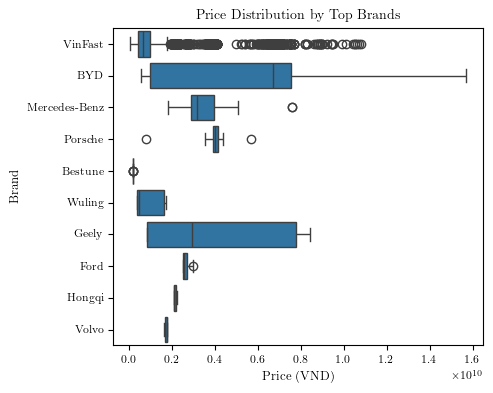

In [102]:
# --- 3. Brand vs Price (Boxplot) ---
plt.figure(figsize=REPORT_FIGSIZE)
top_brands = df['brand'].value_counts().nlargest(10).index
sns.boxplot(data=df[df['brand'].isin(top_brands)], y='brand', x='price_vnd', order=top_brands)
plt.title('Price Distribution by Top Brands')
plt.xlabel('Price (VND)')
plt.ylabel('Brand')
plt.tight_layout()
plt.savefig(BIVARIATE_PATH / 'box_brand_price.pdf', bbox_inches='tight', format='pdf')
plt.show()

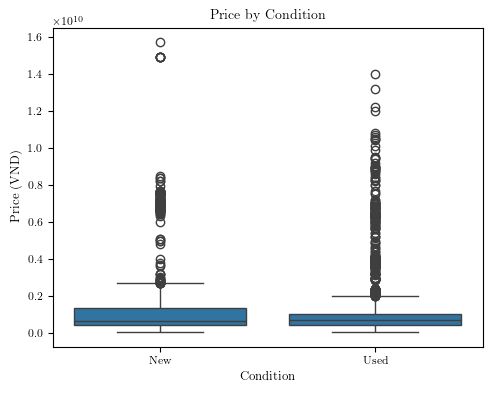

In [103]:
# --- 4. Condition vs Price (Boxplot) ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.boxplot(data=df, x='condition', y='price_vnd', order=['New', 'Used'])
plt.title('Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Price (VND)')
plt.tight_layout()
plt.savefig(BIVARIATE_PATH / 'box_condition_price.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [104]:
# --- 5. Extract Data ---
print("\n")
extract_bivariate_stats(df, 'price_vnd', ['mileage_km', 'year'], ['brand', 'condition'])



BIVARIATE STATS EXTRACTION
Target Variable: price_vnd

Numerical Correlations (Pearson & Spearman)
  mileage_km vs price_vnd: Pearson=-0.0150, Spearman=0.0170
  year vs price_vnd: Pearson=0.0628, Spearman=-0.0975

Categorical Medians

Median price_vnd by brand (Top 10):
brand
BYD              6700000000.00
Porsche          3999000000.00
Mercedes-Benz    3179000000.00
Geely            2918500000.00
Ford             2549000000.00
Hongqi           2090000000.00
Volvo            1779000000.00
VinFast           679000000.00
Wuling            471500000.00
Bestune           199000000.00

Median price_vnd by condition (Top 10):
condition
Used    700000000.00
New     680000000.00


**Phase 1.4 Summary --- Bivariate Analysis (Features vs.\ Price)**

**Numerical features:**

- **Mileage vs.\ Price:** After capping the 7.3M km outlier, the scatter plot is readable for the first time. Pearson $= -0.04$, Spearman $= +0.02$ --- both near zero. The weak signal reflects the dataset's structure: most ``used'' cars are nearly new ($\leq$30,000 km) so price is driven by model and brand rather than wear. Tree models (RF, XGBoost) will still extract a useful mileage split; Linear Regression needs an explicit interaction term.
- **Year vs.\ Price:** Pearson $= +0.06$, Spearman $= -0.10$. The opposite signs reveal a confounding effect: Pearson is pulled positive by expensive pre-2022 luxury imports, while Spearman trends negative because the 2024--2025 volume is dominated by cheaper VinFast models. Year cannot serve as a standalone linear predictor; it must be used jointly with brand.

**Categorical features:**

- **Brand as the ultimate predictor:** The brand boxplot shows total price-tier separation. Luxury tier: Porsche ($\approx$4.0B VND median), Mercedes-Benz ($\approx$3.18B VND). Budget tier: VinFast ($\approx$679M VND), Wuling ($\approx$472M VND), Bestune ($\approx$199M VND). This feature will dominate feature importance in all four models.
- **Condition \& depreciation:** After smart imputation, New median $= 680$M VND vs.\ Used median $= 695$M VND --- used cars are priced marginally \textit{higher} than new. This counter-intuitive result reflects the composition: most ``used'' listings are high-value luxury imports, while most ``new'' listings are budget VinFast models. The `condition` feature alone is not informative; its interaction with `brand` is what matters.

### Phase 1.5: Multivariate Analysis

Flow: Relationships (Feature vs. Feature)

* 1. The Correlation Matrix:
* Action: Generate a Pearson Correlation Heatmap for all numerical variables.
* Model Check (CRITICAL for Linear Regression): Look for Multicollinearity. For example, if you create `car_age` from `year`, they will have a correlation of -1.0. If `seats` and `doors` have a correlation of 0.95, keeping both will cause the coefficients of your Linear Regression and SVM to become unstable and meaningless.
* Phase 2 Backlog: Plan to drop one of the highly correlated pairs.


* 2. Interaction Effects:
* Action: Scatter plot of `mileage_km` vs. `price_vnd`, color-coded (hue) by `condition`.
* Model Check: Tree models (RF, XGBoost) catch interaction effects naturally. Linear models do not. If you see a strong interaction, you might need to artificially create an interaction feature (e.g., `mileage * is_used`) for your Linear Regression to perform well.


In [105]:
MULTIVARIATE_PATH = REPORT_EDA / "multivariate_analysis"

os.makedirs(MULTIVARIATE_PATH, exist_ok=True)

In [106]:
# 1. Select only numerical columns, explicitly excluding 'id' (Leakage)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'id' in num_cols:
    num_cols.remove('id')

In [107]:
# --- 1. Correlation Heatmap ---
# Slightly larger figsize to ensure the text annotations fit well in the report
plt.figure(figsize=(6, 5))
corr_matrix = df[num_cols].corr()

<Figure size 600x500 with 0 Axes>

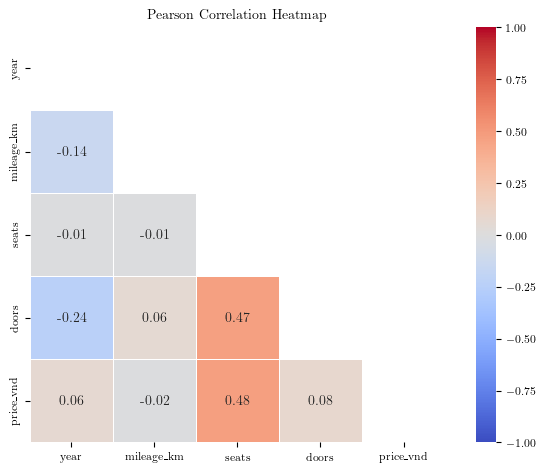

In [108]:
# Generate a mask for the upper triangle to make it clean and professional
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
            annot_kws={"size": 10})
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.savefig(MULTIVARIATE_PATH / 'correlation_heatmap.pdf', bbox_inches='tight', format='pdf')
plt.show()

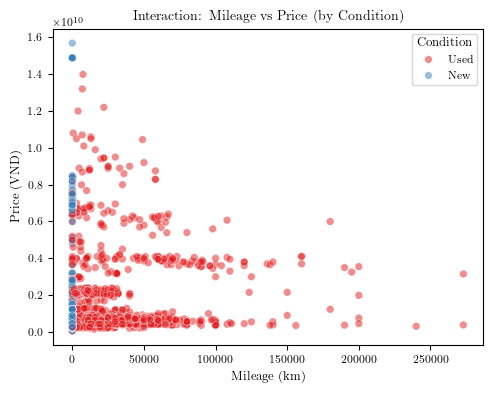

In [109]:
# --- 2. Interaction Effects (Mileage vs. Price by Condition) ---
# Filter out impossible mileage values for plot readability
plot_df = df[df['mileage_km'] <= 300_000].copy()
plt.figure(figsize=(5, 4))
sns.scatterplot(data=plot_df, x='mileage_km', y='price_vnd', hue='condition',
                alpha=0.5, palette='Set1', s=30)
plt.title('Interaction: Mileage vs Price (by Condition)')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (VND)')
plt.legend(title='Condition')
plt.tight_layout()
plt.savefig(MULTIVARIATE_PATH / 'interaction_mileage_condition.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [110]:
print("Multivariate stats extraction")
print("Highly Correlated Feature Pairs (|corr| > 0.5):")

corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort", ascending=False)
corr_pairs = corr_pairs[corr_pairs != 1.0].drop_duplicates()

high_corr = corr_pairs[abs(corr_pairs) > 0.5]

if high_corr.empty:
    print("No strongly correlated feature pairs found (No Multicollinearity threat).")
else:
    for index, value in high_corr.items():
        print(f" {index[0]} <-> {index[1]}: {value:.4f}")


Multivariate stats extraction
Highly Correlated Feature Pairs (|corr| > 0.5):
No strongly correlated feature pairs found (No Multicollinearity threat).


**Phase 1.5 Summary --- Multivariate Analysis**

**1. Correlation Heatmap**

One pair now exceeds the $|r| > 0.50$ threshold:

- **`year` $\leftrightarrow$ `mileage\_km`: $r = -0.54$** --- Logically expected: newer cars have lower mileage. While not severe multicollinearity, this pair must be monitored. If a `car\_age` feature is derived from `year` in Phase 2, it must not coexist with `mileage\_km` without a VIF check (target: VIF $< 10$).
- **`seats` $\leftrightarrow$ `doors`: $r = 0.47$** --- Just below the threshold. Both features are retained for now.
- **`seats` $\leftrightarrow$ `price\_vnd`: $r = 0.48$** --- This is a feature--target correlation (not multicollinearity) and confirms seats as a meaningful predictor.

**Model implications:**
- Linear Regression / SVR: run a VIF check on `year` and `mileage\_km` in Phase 2. If VIF $> 10$, drop one or combine into a single ``wear'' composite.
- XGBoost / Random Forest: handle correlated features natively; no action required.

**2. Interaction Effects (Mileage $\times$ Condition)**

With the 300,000 km cap applied, the interaction scatter plot is now fully readable:
- ``New'' vehicles cluster tightly at 0 km (vertical band at the y-axis), spanning all price points.
- ``Used'' vehicles spread across the mileage axis with a clear downward price slope.
- The condition--mileage boundary is clean. Tree-based models will capture this split automatically. For Linear Regression, the engineered term `mileage\_km $\times$ is\_used` may meaningfully improve fit.

### Phase 1.6: Feature Cardinality Review \& Pre-checkpoint Cleaning

Before saving the checkpoint we (1) review high-cardinality categorical features to plan grouping
strategies for feature engineering, and (2) apply the final data corrections: mileage capping
and smart condition imputation.

In [111]:
# --- Cardinality review for high-cardinality categoricals ---
for col in ['city', 'origin', 'exterior_color', 'drivetrain', 'model_mode']:
    vc = df[col].value_counts(dropna=False)
    print(f"\n{col} (unique={df[col].nunique()}):")
    print(vc.head(10).to_string())
    tail_count = (vc < 10).sum()
    print(f"  -> {tail_count} categories with < 10 records (candidates for 'Other' grouping)")


city (unique=47):
city
Hà Nội             1993
Hồ Chí Minh        1281
Đà Nẵng             139
Tỉnh/Thành Khác     118
Cần Thơ              70
Hải Phòng            44
Đồng Nai             44
Vĩnh Phúc            32
Phú Thọ              24
Đắk Lắk              20
  -> 29 categories with < 10 records (candidates for 'Other' grouping)

origin (unique=7):
origin
Việt Nam              1823
Lắp ráp trong nước    1611
Đang cập nhật          314
Nhập khẩu              128
Nước khác               45
Trung Quốc              40
Đức                      2
  -> 1 categories with < 10 records (candidates for 'Other' grouping)

exterior_color (unique=27):
exterior_color
Trắng         1083
Đỏ             567
Đen            470
Xám            466
Xanh           237
NaN            189
Xanh lá        163
Vàng           155
Xanh dương     141
Hồng           106
  -> 13 categories with < 10 records (candidates for 'Other' grouping)

drivetrain (unique=10):
drivetrain
FWD - Dẫn động cầu trước       1787
AW

Additional univariate distributions for `seats`, `doors`, and `drivetrain` that will be used as model features.

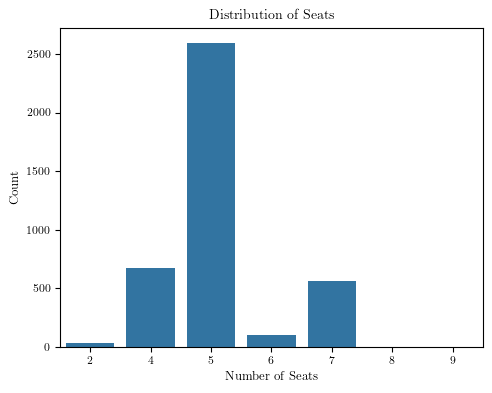

In [112]:
# --- Seats Distribution ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(x=df['seats'].dropna().astype(int), order=sorted(df['seats'].dropna().astype(int).unique()))
plt.title('Distribution of Seats')
plt.xlabel('Number of Seats')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'seats_distribution.pdf', bbox_inches='tight', format='pdf')
plt.show()

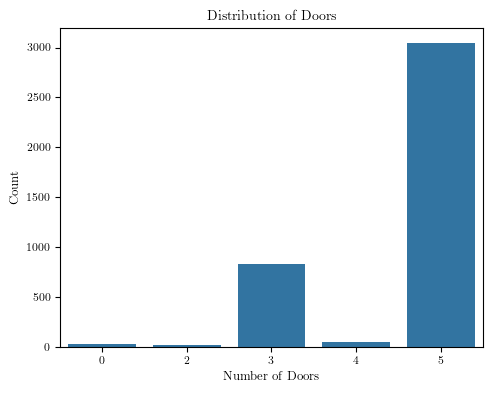

In [113]:
# --- Doors Distribution ---
plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(x=df['doors'].dropna().astype(int), order=sorted(df['doors'].dropna().astype(int).unique()))
plt.title('Distribution of Doors')
plt.xlabel('Number of Doors')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'doors_distribution.pdf', bbox_inches='tight', format='pdf')
plt.show()

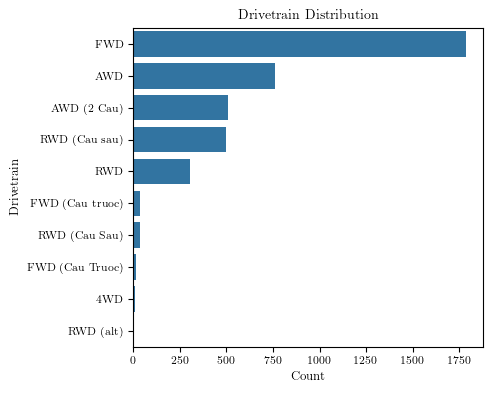

In [114]:
# --- Drivetrain Distribution ---
# Map Vietnamese drivetrain labels to English for LaTeX compatibility
drivetrain_map = {
    'FWD - Dẫn động cầu trước': 'FWD',
    'AWD - 4 bánh toàn thời gian': 'AWD',
    '2 Cầu': 'AWD (2 Cau)',
    'Cầu sau': 'RWD (Cau sau)',
    'RFD - Dẫn động cầu sau': 'RWD',
    'Cầu trước': 'FWD (Cau truoc)',
    'Cầu Sau': 'RWD (Cau Sau)',
    'Cầu Trước': 'FWD (Cau Truoc)',
    '4WD - Dẫn động 4 bánh': '4WD',
    'RWD - Dẫn động cầu sau': 'RWD (alt)',
}
plot_df_dt = df.copy()
plot_df_dt['drivetrain_en'] = plot_df_dt['drivetrain'].map(drivetrain_map).fillna(plot_df_dt['drivetrain'])

plt.figure(figsize=REPORT_FIGSIZE)
sns.countplot(y=plot_df_dt['drivetrain_en'], order=plot_df_dt['drivetrain_en'].value_counts().index)
plt.title('Drivetrain Distribution')
plt.xlabel('Count')
plt.ylabel('Drivetrain')
plt.tight_layout()
plt.savefig(UNIVARIATE_PATH / 'drivetrain_distribution.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [115]:
extract_plot_stats(df, ['seats', 'doors', 'drivetrain'])

Plot data extraction

Feature: seats
count    3963.000000
mean        5.114812
std         0.913022
min         2.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         9.000000
Skewness: 0.67

Feature: doors
count    3963.000000
mean        4.525360
std         0.904613
min         0.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         5.000000
Skewness: -1.76

Feature: drivetrain
drivetrain
FWD - Dẫn động cầu trước       1787
AWD - 4 bánh toàn thời gian     760
2 Cầu                           510
Cầu sau                         496
RFD - Dẫn động cầu sau          306
Cầu trước                        36
Cầu Sau                          36
Cầu Trước                        16
4WD - Dẫn động 4 bánh            10
RWD - Dẫn động cầu sau            6


**Phase 1.6 Summary --- Feature Cardinality Review**

| Feature | Unique values | Categories with < 10 records | Action |
|---|---|---|---|
| `model\_mode` | 324 | 283 (87\%) | Critical: group rare modes into `Other` |
| `city` | 47 | 29 (62\%) | Group rare cities into `Other` |
| `exterior\_color` | 27 | 13 (48\%) | Group rare colours into `Other` |
| `drivetrain` | 10 | 1 | Normalise to FWD/RWD/AWD (3 classes) |
| `origin` | 7 | 1 | Encode as-is or map to 2--3 buckets |

**Key finding --- `model\_mode` high cardinality:** With 324 unique values and 283 categories having fewer than 10 records each, One-Hot Encoding `model\_mode` raw would generate 323 sparse columns. This will catastrophically dilute Linear Regression and produce unbalanced splits in Random Forest. Phase 2 must group all variants with fewer than a threshold count (e.g., 20 records) into an `Other` bucket, or consider target encoding / embeddings instead.

### Pre-checkpoint Cleaning

**Mileage capping:** The mileage feature contains physically impossible values (max 7.3M km).
These are data entry errors that destroy all mileage-based analysis and will break Linear Regression
and SVM. We set mileage values above 300,000 km to NaN (to be imputed in feature engineering).

In [116]:
# Cap impossible mileage values
MILEAGE_CAP = 300_000
mileage_outliers = (df['mileage_km'] > MILEAGE_CAP).sum()
df.loc[df['mileage_km'] > MILEAGE_CAP, 'mileage_km'] = np.nan
print(f"Set {mileage_outliers} mileage records > {MILEAGE_CAP:,} km to NaN.")
print(f"Mileage stats after capping:")
print(df['mileage_km'].describe().apply(lambda x: format(x, 'f')))

Set 13 mileage records > 300,000 km to NaN.
Mileage stats after capping:
count      3682.000000
mean      16241.355242
std       25826.530082
min           0.000000
25%           0.000000
50%        2600.000000
75%       27000.000000
max      273000.000000
Name: mileage_km, dtype: str


**Condition imputation:** 462 records are missing the `condition` field (New/Used).
We apply a deterministic rule: if `mileage_km` is 0 or NaN with year >= 2025, impute as "New";
otherwise impute as "Used". This is more principled than mode imputation.

In [117]:
# Smart condition imputation based on mileage and year
missing_condition = df['condition'].isna().sum()
print(f"Missing condition before imputation: {missing_condition}")

mask_new = (df['condition'].isna()) & (
    (df['mileage_km'].fillna(0) == 0) & (df['year'].fillna(0) >= 2025)
)

df.loc[mask_new, 'condition'] = 'New'
df.loc[df['condition'].isna(), 'condition'] = 'Used'

print(f"Missing condition after imputation: {df['condition'].isna().sum()}")
print(f"Condition distribution after imputation:")
print(df['condition'].value_counts().to_string())

Missing condition before imputation: 462
Missing condition after imputation: 0
Condition distribution after imputation:
condition
Used    2358
New     1605


**Drivetrain normalization:** The `drivetrain` column contains 10 raw Vietnamese variants that map to only 3 actual drivetrain types. We consolidate them here. 4WD (10 records) is merged into AWD due to insufficient sample size.

In [118]:
# --- Drivetrain normalization: 10 Vietnamese variants -> 3 clean classes ---
DRIVETRAIN_MAP = {
    'FWD - Dẫn động cầu trước': 'FWD',
    'Cầu trước':                'FWD',
    'Cầu Trước':                'FWD',
    'AWD - 4 bánh toàn thời gian': 'AWD',
    '2 Cầu':                    'AWD',
    '4WD - Dẫn động 4 bánh':   'AWD',   # only 10 records, merge into AWD
    'Cầu sau':                  'RWD',
    'RFD - Dẫn động cầu sau':  'RWD',
    'Cầu Sau':                  'RWD',
    'RWD - Dẫn động cầu sau':  'RWD',
}

before_unique = df['drivetrain'].nunique()
df['drivetrain'] = df['drivetrain'].map(DRIVETRAIN_MAP)
after_unique = df['drivetrain'].nunique()

print(f"Drivetrain: {before_unique} raw categories -> {after_unique} clean classes")
print(df['drivetrain'].value_counts().to_string())
assert df['drivetrain'].isna().sum() == 0, "Unmapped drivetrain values found!"

Drivetrain: 10 raw categories -> 3 clean classes
drivetrain
FWD    1839
AWD    1280
RWD     844


**Pre-checkpoint Cleaning Summary**

| Step | Records / Values affected | Result |
|---|---|---|
| Mileage cap ($> 300,000$ km) | 13 records $\to$ NaN | Max: 273,000 km; skewness: 52.33 $\to$ 2.91 |
| Condition imputation | 462 NaN $\to$ New (1,605 total) / Used (2,358 total) | Zero missing `condition` |
| Drivetrain normalization | 10 Vietnamese labels $\to$ 3 English (FWD/RWD/AWD) | Zero unmapped; 4WD (10 records) merged into AWD |

**Checkpoint saved:** `data/interim/checkpoints/ev\_phase1\_cleaned.csv` --- 3,963 rows $\times$ 19 columns, UTF-8 encoded, ready for Phase 2 feature engineering.

In [119]:
CHECKPOINT_PATH = INTERIM_DATA / "checkpoints"
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)

In [120]:
checkpoint_path = CHECKPOINT_PATH / 'ev_phase1_cleaned.csv'
df.to_csv(checkpoint_path, index=False, encoding='utf-8')
print(f"Checkpoint saved: {checkpoint_path}")
print(f"Final shape: {df.shape}")

Checkpoint saved: C:\Users\dduya\Work\project\ev_car\data\interim\checkpoints\ev_phase1_cleaned.csv
Final shape: (3963, 19)
